## Deep Learning

### Chapter 11: The Pre-Trained VGG16 Model

VGG16 is a popular convolutional neural network architecture that was developed by the Visual Geometry Group at the University of Oxford. It is known for its simplicity and effectiveness in image classification tasks. The VGG16 model consists of 16 layers, including convolutional layers, pooling layers, and fully connected layers.

The architecture of VGG16 is as follows:
1. **Input Layer**: The input to the VGG16 model is a 224x224 RGB image.

2. **Convolutional Layers**: The model has 13 convolutional layers that use small 3x3 filters to capture local features from the input image. The number of filters increases as we go deeper into the network, starting from 64 filters in the first convolutional layer and going up to 512 filters in the deeper layers.

3. **Pooling Layers**: After every few convolutional layers, there are max pooling layers that reduce the spatial dimensions of the feature maps, helping to control overfitting and improve computational efficiency.

4. **Fully Connected Layers**: The model has three fully connected layers at the end, with the last layer having 1000 neurons corresponding to the 1000 classes in the ImageNet dataset.

5. **Output Layer**: The output layer uses a softmax activation function to produce a probability distribution over the 1000 classes.

### Leveraging the Pre-Trained VGG16 Model
To leverage the pre-trained VGG16 model for a new image classification task, we can use the following steps:

Step 1 — Load the Pre-Trained Convolutional Base

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
try:
    conv_base = keras.applications.vgg16.VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(180, 180, 3),)
    print("Loaded VGG16 pretrained on ImageNet.")

except Exception as e:
    print("Unable to download ImageNet weights.")
    print("Using weights=None instead.")
    print("Error:", repr(e))

    conv_base = keras.applications.vgg16.VGG16(
        weights=None,
        include_top=False,
        input_shape=(180, 180, 3),)

Loaded VGG16 pretrained on ImageNet.


Step 2 — Freeze the Convolutional Base

In [4]:
conv_base.trainable = False
print("Trainable weights:", len(conv_base.trainable_weights))

conv_base.summary()

Trainable weights: 0


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

Step 3 — Build a New Classifier

In [5]:
inputs = keras.Input(shape=(32, 32, 3))

x = layers.Resizing(180, 180)(inputs)

x = layers.Lambda(lambda img:
                  keras.applications.vgg16.preprocess_input(img * 255.0),
                  name="vgg16_preprocess")(x)

x = conv_base(x, training=False)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1,activation="sigmoid")(x)

feature_model = keras.Model(inputs, outputs)

Step 4 — Compile the Model

In [6]:
feature_model.compile(optimizer="rmsprop",
                      loss="binary_crossentropy", metrics=["accuracy"],)
feature_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_preprocess (Lambda)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,992,001 (68.63 MB)

 Trainable params: 3,277,313 (12.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Step 5 — Train the New Classifier

In [7]:
def plot_history(history, name):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, "bo", label="Training acc")
    plt.plot(epochs, val_acc, "b", label="Validation acc")
    plt.title("Training and validation accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()

    plt.show()

In [8]:
x_cd_train = np.random.rand(100, 32, 32, 3)
y_cd_train = np.random.randint(2, size=(100, 1))

x_cd_val = np.random.rand(20, 32, 32, 3)
y_cd_val = np.random.randint(2, size=(20, 1))

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 0.5200 - loss: 28.3992 - val_accuracy: 0.6500 - val_loss: 15.1490
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - accuracy: 0.5200 - loss: 13.4850 - val_accuracy: 0.6500 - val_loss: 7.6391
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 42s 8s/step - accuracy: 0.5200 - loss: 8.0134 - val_accuracy: 0.6000 - val_loss: 2.7540
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.6000 - loss: 4.2925 - val_accuracy: 0.3000 - val_loss: 4.7865
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - accuracy: 0.6700 - loss: 2.5456 - val_accuracy: 0.3500 - val_loss: 7.6973
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 7s/step - accuracy: 0.7000 - loss: 2.1535 - val_accuracy: 0.4500 - val_loss: 2.3631
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - accuracy: 0.7600 - loss: 0.7953 - val_accuracy: 0.6500 - val_loss: 5.8154
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - accuracy: 0.8000 - loss: 1.0192 - val_accuracy: 0.6500 - val_loss: 6.1161
Epoch

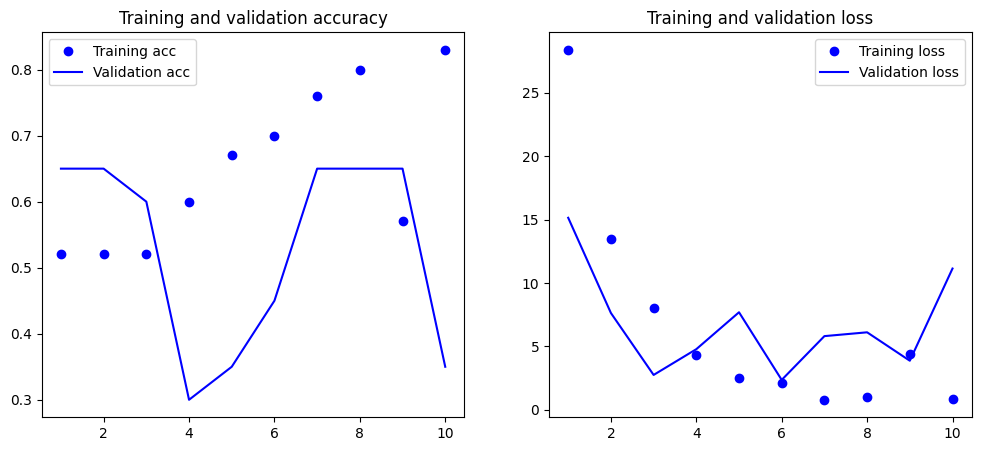

In [9]:
RUN_FEATURE_EXTRACTION = True
FAST_RUN = False

if RUN_FEATURE_EXTRACTION:

    history_feature = feature_model.fit(
        x_cd_train,
        y_cd_train,
        epochs=2 if FAST_RUN else 10,
        batch_size=32,
        validation_data=(x_cd_val, y_cd_val),)

    plot_history(history_feature, "Feature Extraction with VGG16")

else:
    print("Feature extraction training skipped.")

### Fine-Tuning the Pre-Trained Model

Fine-tuning is a technique where we unfreeze some of the layers of the pre-trained model and train them along with the new classifier. This allows the model to learn more specific features relevant to the new task while still benefiting from the general features learned from the original dataset.

For VGG16, we can unfreeze the last few convolutional layers and train them along with the new classifier. This can be done by setting the `trainable` attribute of the layers to `True` and recompiling the model before training.

Top Layer Fine-Tuning: Unfreeze only the last convolutional block (the last 4 convolutional layers) and train them along with the new classifier.

Step 1 — Unfreeze Block 5

In [10]:
conv_base.trainable = True

for layer in conv_base.layers:
    layer.trainable = (layer.name.startswith("block5"))

In [11]:
print("Trainable Layers:")
for layer in conv_base.layers:
    if layer.trainable:
        print("-", layer.name)

Trainable Layers:
- block5_conv1
- block5_conv2
- block5_conv3
- block5_pool


Step 2 — Recompile with a Small Learning Rate

In [12]:
feature_model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
                      loss="binary_crossentropy",
                      metrics=["accuracy"],)

Step 3 — Continue Training

In [13]:
x_cd_train = np.random.rand(100, 32, 32, 3)
y_cd_train = np.random.randint(2, size=(100, 1))

x_cd_val = np.random.rand(20, 32, 32, 3)
y_cd_val = np.random.randint(2, size=(20, 1))

In [14]:
def plot_history(history, name):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, "bo", label="Training acc")
    plt.plot(epochs, val_acc, "b", label="Validation acc")
    plt.title("Training and validation accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()

    plt.show()

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 36s 8s/step - accuracy: 0.4800 - loss: 5.1946 - val_accuracy: 0.6500 - val_loss: 1.2261
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 0.4500 - loss: 1.8430 - val_accuracy: 0.6500 - val_loss: 0.9670
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 0.5200 - loss: 1.4824 - val_accuracy: 0.5500 - val_loss: 0.7426
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 41s 8s/step - accuracy: 0.5400 - loss: 1.1676 - val_accuracy: 0.5500 - val_loss: 0.7116
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 35s 8s/step - accuracy: 0.5700 - loss: 1.1953 - val_accuracy: 0.7000 - val_loss: 0.6770
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 38s 9s/step - accuracy: 0.6300 - loss: 0.9272 - val_accuracy: 0.6000 - val_loss: 0.7712
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 35s 8s/step - accuracy: 0.6100 - loss: 0.9056 - val_accuracy: 0.6500 - val_loss: 0.6904
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 35s 8s/step - accuracy: 0.6400 - loss: 0.6791 - val_accuracy: 0.7000 - val_loss: 0.6487
Epoch 9/

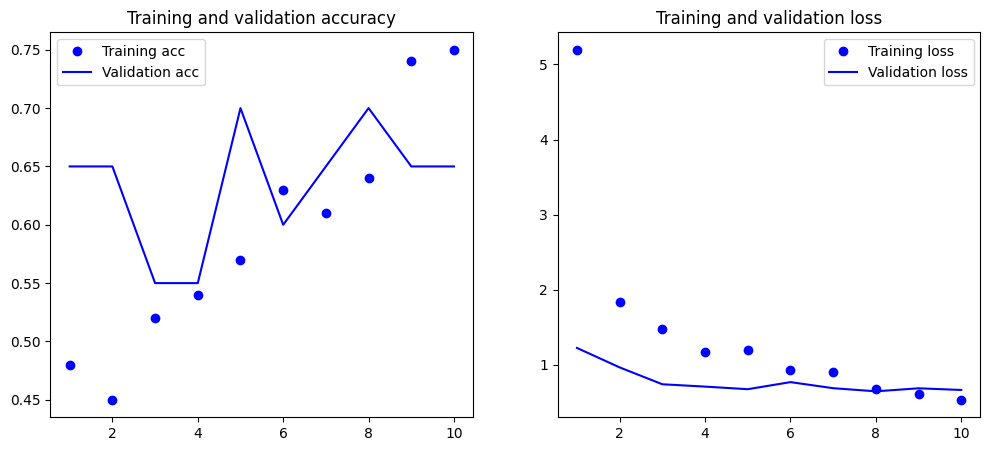

In [15]:
RUN_FINE_TUNING = True
FAST_RUN = False

if RUN_FINE_TUNING:
    history_finetune = feature_model.fit(x_cd_train, y_cd_train,
                                          epochs=2 if FAST_RUN else 10,
                                          batch_size=32,
                                          validation_data=(x_cd_val, y_cd_val))

    plot_history(history_finetune, "Fine-Tuning VGG16")
else:
    print("Fine-tuning skipped.")

### Applying VGG16 to the Oxford-IIIT Pets Dataset

The Oxford-IIIT Pets dataset is a popular dataset for image classification tasks, containing images of 37 different breeds of cats and dogs. We can apply the VGG16 model to this dataset by following the steps outlined above for both feature extraction and fine-tuning.

VGG16 can be used to extract features from the images in the Oxford-IIIT Pets dataset, and then a new classifier can be trained on top of these features to classify the images into the 37 different breeds. Additionally, fine-tuning can be performed to further improve the performance of the model on this specific dataset.

Note that the size of the input images in the Oxford-IIIT Pets dataset may need to be resized to 224x224 pixels to be compatible with the VGG16 model. And its overall size is around 200MB, which is manageable for most applications.

In [16]:
import tensorflow_datasets as tfds

# Load only the first 1000 samples of the train split
dataset, info = tfds.load("oxford_iiit_pet", split="train[:1000]",
                          with_info=True, as_supervised=True)

# Verify the number of loaded samples
print(f"Loaded samples: {len(dataset)}")
print(info)

Loaded samples: 1000
tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
        'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
        'image': Image(shape=(None, None, 3), dtype=uint8),
    

In [17]:
# Image preprocessing
IMG_SIZE = (180, 180)

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [18]:
# Load VGG16 convolutional base

conv_base = keras.applications.VGG16(weights="imagenet",
                                     include_top=False, input_shape=(180, 180, 3))
conv_base.trainable = False

In [19]:
# Build classifier

inputs = keras.Input(shape=(180, 180, 3))

x = keras.applications.vgg16.preprocess_input(inputs * 255.0)
x = conv_base(x, training=False)

x = layers.Flatten()(x)

x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(37, activation="softmax")(x)

pet_model = keras.Model(inputs, outputs)
pet_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

pet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 180, 180,  │          0 │ input_layer_3[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 180, 180)  │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 180, 180)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 180, 180)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 180, 180,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 180, 180,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 5, 5, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 12800)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │  6,554,112 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 37)        │     18,981 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,287,781 (81.21 MB)

 Trainable params: 6,573,093 (25.07 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
history = pet_model.fit(dataset.map(preprocess).batch(32),
                        epochs=2)

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 250s 8s/step - accuracy: 0.2350 - loss: 43.6423
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 253s 8s/step - accuracy: 0.5940 - loss: 5.1539
